<a href="https://colab.research.google.com/github/nairnavya/brain-connectivity-viewer/blob/main/eeg_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install moabb mne pyriemann -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 98.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [ ]:
from moabb.datasets import BNCI2014_001 # motor imagery experiment; all trials are motor imagery tasks
from moabb.paradigms import MotorImagery # "interpret this dataset as a motor imagery task and epoch it accordingly"

In [ ]:
dataset = BNCI2014_001()
paradigm = MotorImagery()
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1]) # X = data, y = labels

/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


In [ ]:
print(X.shape) # 576 trials, 22 channels, 1001 time points
print(set(y)) # names of all states

(576, 22, 1001)
{np.str_('feet'), np.str_('right_hand'), np.str_('tongue'), np.str_('left_hand')}


In [ ]:
paradigm = MotorImagery(events=['left_hand', 'right_hand'], n_classes=2)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])
print(X.shape)

(288, 22, 1001)


In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

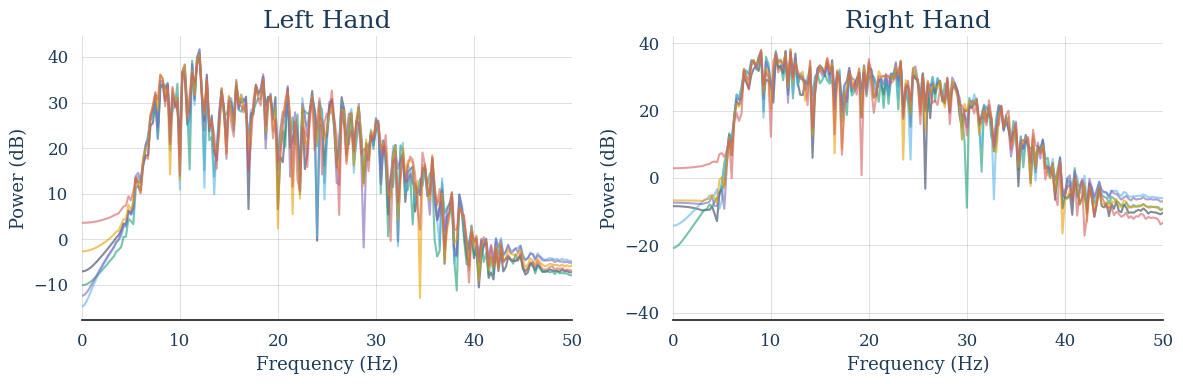

In [ ]:
X_left = X[y == 'left_hand'] # take left_hand data
X_right = X[y == 'right_hand'] # take right_hand data

sfreq = 250 # define sampling freq
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # 2 plots on same graph of width 12 and height 4

for ax, data, label in zip(axes, [X_left, X_right], ['Left Hand', 'Right Hand']):
    mean_trial = data.mean(axis=0)  # one average 4 second voltage array per channel; shape (22, 1001) - 22 channels, 1001 time points
    ax.set_title(label)
    for ch in range(0, 6):  # first 6 channels
        freqs = np.fft.rfftfreq(1001, d=1/sfreq) # create x-axis such that maximum frequency is half the sampling frequency
        psd = np.abs(np.fft.rfft(mean_trial[ch]))**2 # takes one channel's time series, performs fourier transform, computers power at each freq
        ax.plot(freqs, 10 * np.log10(psd), alpha=0.6) # plots frequency versus power
    ax.set_xlim(0, 50)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')

plt.tight_layout()
plt.show()

# power is inversely proportional to frequency - low frequencies have high power, high frequencies have low power
# pink noise - straight downward slope from left to right

In [ ]:
subject_data = dataset.get_data(subjects=[1])
sessions = subject_data[1]
print(sessions.keys())

dict_keys(['0train', '1test'])


In [ ]:
runs = sessions['0train']
print(runs.keys())

dict_keys(['0', '1', '2', '3', '4', '5'])


In [ ]:
raw = runs['0']
print(raw.info['ch_names'])

['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz', 'EOG1', 'EOG2', 'EOG3', 'STI']


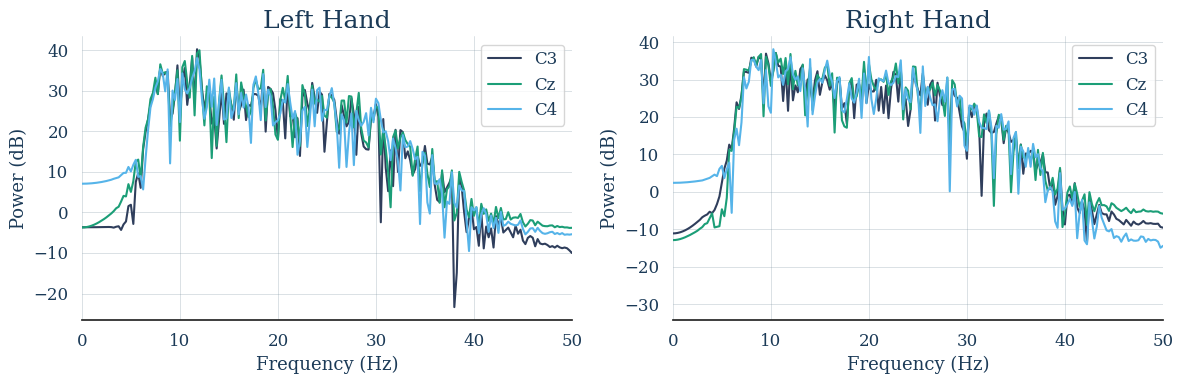

In [ ]:
motor_channels = [7, 9, 11]  # C3, Cz, C4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, label in zip(axes, [X_left, X_right], ['Left Hand', 'Right Hand']):
    mean_trial = data.mean(axis=0)
    ax.set_title(label)
    for ch_idx, ch_name in zip(motor_channels, ['C3', 'Cz', 'C4']):
        freqs = np.fft.rfftfreq(1001, d=1/sfreq)
        psd = np.abs(np.fft.rfft(mean_trial[ch_idx]))**2
        ax.plot(freqs, 10 * np.log10(psd), label=ch_name)
    ax.set_xlim(0, 50)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power (dB)')
    ax.legend()

plt.tight_layout()
plt.show()